# GENCYS 2.0 - Exercise No. 1

# Quantum Random Number Generator

### Qiskit 2.5.2 - Google Colab Notebook

In this exercise, we will build a simple **Quantum Random Number Generator (QRNG)** using a **Hadamard gate**.

We will:

- create a qubit in Qiskit
- apply a Hadamard (`H`) gate
- measure the qubit
- simulate the circuit multiple times
- generate random bits
- combine multiple qubits to generate larger random numbers

> **Note:** Qiskit Aer is a classical simulator. It reproduces the measurement statistics of a quantum circuit, but the samples here come from a simulator rather than physical quantum hardware.


## Classical Bit vs Qubit

A classical bit can be in exactly one state:

$$
0 \quad \text{or} \quad 1
$$

A qubit can be prepared in a **superposition**:

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle
$$

For this exercise, we start with:

$$
|0\rangle
$$

and apply a **Hadamard gate**:

$$
H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

When we measure this state:

- Probability of `0` = $\frac{1}{2}$
- Probability of `1` = $\frac{1}{2}$

So this circuit behaves like a 50-50 coin flip.

### Circuit

```text
|0> --- H --- Measure
```


## Install Qiskit

Run this cell first in Google Colab.

It installs Qiskit 2.5.2, Qiskit Aer for simulation, and `pylatexenc` for circuit drawing.


In [9]:
!pip install -q "qiskit==2.5.2" "qiskit-aer~=0.17" pylatexenc ipywidgets

## Import Qiskit and Check the Version


## Build the First Quantum Circuit

We use:

- **1 qubit**
- **1 classical bit**

The qubit stores the quantum state. The classical bit stores the result after measurement.


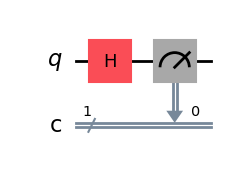

In [12]:
from qiskit.circuit import QuantumCircuit

qc = QuantumCircuit(1, 1)

# Put the qubit into superposition
qc.h(0)

# Measure qubit 0 and store the result in classical bit 0
qc.measure(0, 0)

qc.draw("mpl")

## What Did the Hadamard Gate Do?

Before the Hadamard gate:

$$
|\psi\rangle = |0\rangle
$$

After the Hadamard gate:

$$
|\psi\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

Now we inspect the state **before measurement**.


### Understanding the Statevector

For one qubit, Qiskit returns two amplitudes:

```text
[a, b]
```

where:

- `a` is the amplitude of $|0\rangle$
- `b` is the amplitude of $|1\rangle$

After applying the Hadamard gate to $|0\rangle$, the state is:

$$
|\psi\rangle = \frac{1}{\sqrt{2}}|0\rangle + \frac{1}{\sqrt{2}}|1\rangle
$$

Since:

$$
\frac{1}{\sqrt{2}} \approx 0.707
$$

the statevector is approximately:

```text
[0.707+0.j, 0.707+0.j]
```

To get measurement probabilities, square the magnitude of each amplitude:

$$
|0.707|^2 \approx 0.5
$$

So the probabilities are:

```text
0 -> 0.5
1 -> 0.5
```


In [14]:
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import Statevector

state_circuit = QuantumCircuit(1)
state_circuit.h(0)

state = Statevector.from_instruction(state_circuit)

print("Statevector:")
print(state)

print("\nProbabilities:")
print(state.probabilities_dict())

Statevector:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Probabilities:
{np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


## Simulate 1000 Measurements

A single measurement gives one result.

To see the probability distribution, we run the same circuit many times. Each execution is called a **shot**.


Measurement counts: {'0': 507, '1': 493}


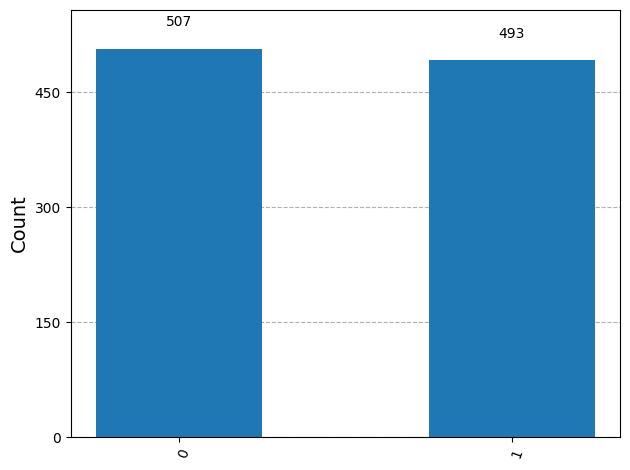

In [17]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

simulator = AerSimulator()

compiled_circuit = transpile(qc, simulator)

job = simulator.run(compiled_circuit, shots=1000)
result = job.result()

counts = result.get_counts(compiled_circuit)

print("Measurement counts:", counts)

plot_histogram(counts)

### What should happen?

You should get something approximately like:

```text
{'0': 492, '1': 508}
```

The exact numbers will usually change each time.

They do **not** need to be exactly 500 and 500.

With many shots, they should tend toward roughly:

```text
50% → 0
50% → 1
```

## Generate One Random Bit

Instead of running the circuit 1000 times, we now run it once.

That single measurement becomes our random bit.


In [19]:
def quantum_random_bit():
    circuit = QuantumCircuit(1, 1)

    circuit.h(0)
    circuit.measure(0, 0)

    compiled = transpile(circuit, simulator)

    result = simulator.run(compiled, shots=1).result()
    counts = result.get_counts(compiled)

    # The dictionary contains exactly one measured bit string.
    random_bit = next(iter(counts))

    return int(random_bit)

bit = quantum_random_bit()

print("Random bit:", bit)

Random bit: 1


Run the previous cell repeatedly.

You should get either:

```text
Random bit: 0
```

or:

```text
Random bit: 1
```

This is the basic Hadamard-gate random bit generator.


## Generate a Multi-Bit Random Number

A single qubit gives one bit: `0` or `1`.

With multiple qubits, we can generate a binary number. For example, 4 qubits can produce values from `0000` to `1111`, which correspond to decimal values from 0 to 15.

For $n$ qubits, the number of possible bit strings is:

$$
2^n
$$


Measured bits: 0101
Random number: 5


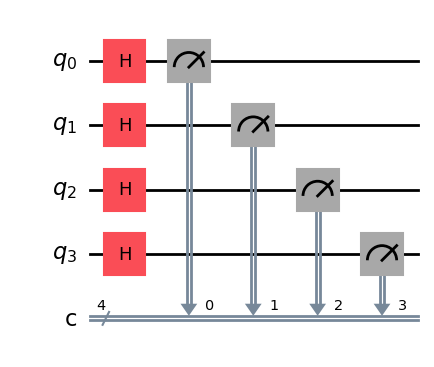

In [20]:
def quantum_random_number(num_bits=4):
    circuit = QuantumCircuit(num_bits, num_bits)

    circuit.h(range(num_bits))
    circuit.measure(range(num_bits), range(num_bits))

    compiled = transpile(circuit, simulator)

    result = simulator.run(compiled, shots=1).result()
    counts = result.get_counts(compiled)

    bit_string = next(iter(counts))
    number = int(bit_string, 2)

    return number, bit_string, circuit


number, bits, random_number_circuit = quantum_random_number(4)

print("Measured bits:", bits)
print("Random number:", number)

random_number_circuit.draw("mpl")

## Interactive Random-Number Generator

Choose how many qubits to use, then press the button. More qubits create a larger range of possible numbers.

In [ ]:
import ipywidgets as widgets
from IPython.display import clear_output, display

rng_width = widgets.IntSlider(value=4, min=1, max=10, step=1, description="Qubits:")
rng_button = widgets.Button(description="Generate", button_style="success")
rng_output = widgets.Output()

def generate_interactive_number(_):
    value, bit_string, _ = quantum_random_number(rng_width.value)
    with rng_output:
        clear_output(wait=True)
        print(f"Measured {bit_string} = {value}")
        print(f"Possible range: 0 to {2 ** rng_width.value - 1}")

rng_button.on_click(generate_interactive_number)
display(widgets.VBox([rng_width, rng_button, rng_output]))


## Exercise 1: Build a Quantum Dice

A normal die should generate:

```text
1, 2, 3, 4, 5, or 6
```

Three qubits generate 8 possible values:

```text
000 -> 0
001 -> 1
010 -> 2
011 -> 3
100 -> 4
101 -> 5
110 -> 6
111 -> 7
```

Your task is to write a `quantum_dice()` function using `quantum_random_number(3)`.

Requirements:

1. Generate a 3-bit random number.
2. Accept only values from `0` to `5`.
3. Convert the accepted value to a die result from `1` to `6`.
4. If the generated value is `6` or `7`, generate another number.

Do not use Python's `random` module.


In [ ]:
# Write your code here.
# Build your quantum_dice() function below.


## Exercise 2: Try It Yourself

Try modifying the notebook to build one of these.

### Easy
- Quantum coin flip
- Quantum dice
- Generate an 8-bit random number

### Medium
- Generate a random number from `0-255`
- Generate a random binary password
- Generate 1000 random bits and count the number of `0`s and `1`s

### Extra
Create a simple Heads or Tails game:

```text
Choose Heads or Tails: Heads

Quantum computer is flipping...

Result: Heads

YOU WIN
```


In [ ]:
# Write your code here.


## What We Learned

The core QRNG circuit is:

```text
|0> --- H --- M
```

It introduces several basic ideas in quantum computing:

1. **Qubit** - the basic unit of quantum information
2. **Superposition** - a quantum state can contain amplitudes for multiple measurement outcomes
3. **Hadamard gate** - creates an equal superposition from $|0\rangle$
4. **Measurement** - converts the quantum state into a classical result
5. **Shots** - repeated circuit executions reveal the probability distribution
6. **Quantum circuits** - gates and measurements describe a quantum computation

### Simulator vs quantum hardware

In this notebook, the circuit is executed using **Qiskit Aer**.

Aer runs on a classical computer and simulates the expected behavior of the quantum circuit. The same circuit idea can later be run on real quantum hardware.
